In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/laptop_prices.csv')
print(df.shape)

(1275, 23)


In [3]:
top5_brands = df['Company'].value_counts().head(5)
print(top5_brands)

Company
Dell      291
Lenovo    289
HP        268
Asus      152
Acer      101
Name: count, dtype: int64


In [4]:
avg_price = df.groupby('Company')['Price_euros'].mean().sort_values(ascending=False)
print(avg_price)
print(f"Highest: {avg_price.idxmax()} ({avg_price.max():.0f}€)")
print(f"Lowest: {avg_price.idxmin()} ({avg_price.min():.0f}€)")

Company
Razer        3346.142857
LG           2099.000000
MSI          1728.908148
Google       1677.666667
Microsoft    1612.308333
Apple        1564.198571
Huawei       1424.000000
Samsung      1413.444444
Toshiba      1267.812500
Dell         1199.225120
Xiaomi       1133.462500
Asus         1123.829737
Lenovo       1093.862215
HP           1080.314664
Fujitsu       729.000000
Acer          633.464455
Chuwi         314.296667
Mediacom      295.000000
Vero          217.425000
Name: Price_euros, dtype: float64
Highest: Razer (3346€)
Lowest: Vero (217€)


Price_euros    1.000000
Ram            0.740287
CPU_freq       0.428847
Weight         0.211883
Inches         0.070091
Name: Price_euros, dtype: float64


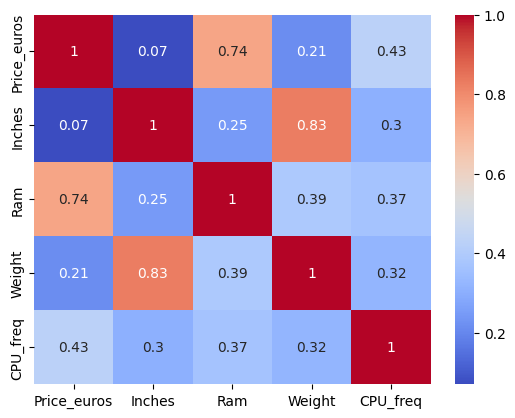

In [5]:
num_cols = ['Price_euros', 'Inches', 'Ram', 'Weight', 'CPU_freq']
corr_price = df[num_cols].corr()['Price_euros'].sort_values(ascending=False)
print(corr_price)
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [6]:
df['PrimaryStorage'] = pd.to_numeric(df['PrimaryStorage'], errors='coerce').fillna(0)
df['SecondaryStorage'] = pd.to_numeric(df['SecondaryStorage'], errors='coerce').fillna(0)
df['StorageTotal'] = df['PrimaryStorage'] + df['SecondaryStorage']
print(df[['PrimaryStorage', 'SecondaryStorage', 'StorageTotal']].head())

   PrimaryStorage  SecondaryStorage  StorageTotal
0             128                 0           128
1             128                 0           128
2             256                 0           256
3             512                 0           512
4             256                 0           256


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
reg_features = ['Ram', 'Inches', 'CPU_freq', 'PrimaryStorage', 'GPU_company']
target = 'Price_euros'
reg_df = df[reg_features + [target]].dropna()
X_reg = reg_df[reg_features]
y_reg = reg_df[target]


In [8]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

numeric_reg = ['Ram', 'Inches', 'CPU_freq', 'PrimaryStorage']
cat_reg = ['GPU_company']
preprocessor = ColumnTransformer([('num', 'passthrough', numeric_reg),
                                  ('cat', OneHotEncoder(handle_unknown='ignore'), cat_reg)])

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

models = {'Linear': LinearRegression(), 'Ridge': Ridge(), 'Lasso': Lasso(),
          'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42)}

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: RMSE={rmse:.0f}, R2={r2:.3f}")

best_reg = max(models, key=lambda k: r2_score(y_test, Pipeline([('pre', preprocessor), ('model', models[k])]).fit(X_train, y_train).predict(X_test)))
print(f"Best Regression: {best_reg}")

Linear: RMSE=467, R2=0.637
Ridge: RMSE=467, R2=0.637
Lasso: RMSE=467, R2=0.637
RandomForest: RMSE=346, R2=0.801
Best Regression: RandomForest


In [9]:
cls_features = ['Inches', 'Ram', 'PrimaryStorage', 'Weight']
target_cls = 'TypeName'
cls_df = df[cls_features + [target_cls]].dropna()
X_cls = cls_df[cls_features]
y_cls = cls_df[target_cls]

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

preprocessor_cls = ColumnTransformer([('num', 'passthrough', cls_features)])
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

cls_models = {'DecisionTree': DecisionTreeClassifier(random_state=42),
              'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
              'SVM': SVC(kernel='rbf')}

for name, model in cls_models.items():
    pipe = Pipeline([('pre', preprocessor_cls), ('model', model)])
    pipe.fit(Xc_train, yc_train)
    yc_pred = pipe.predict(Xc_test)
    acc = accuracy_score(yc_test, yc_pred)
    print(f"{name}: {acc:.3f}")

DecisionTree: 0.737
RandomForest: 0.793
SVM: 0.554
